In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

CURRENT_YEAR = 2025

In [2]:
# Load training data
train_df = pd.read_csv('../data/preprocessed/train.csv')

# Check the year columns
print("Year columns in dataset:")
print(f"  End_target_year: {train_df['End_target_year'].dtype}")
print(f"  Interim_target_year: {train_df['Interim_target_year'].dtype}")
print(f"\nEnd_target_year range: {train_df['End_target_year'].min()} - {train_df['End_target_year'].max()}")
print(f"Interim_target_year range: {train_df['Interim_target_year'].min()} - {train_df['Interim_target_year'].max()}")

Year columns in dataset:
  End_target_year: float64
  Interim_target_year: float64

End_target_year range: 1000.0 - 2070.0
Interim_target_year range: 2020.0 - 2050.0


## 1. Engineer Date-Time Features

We'll create 3+ features from the year columns:

In [3]:
def engineer_datetime_features(df, current_year=2025):
    """
    Engineer date-time features from year columns.
    
    Features created:
    1. years_to_end_target: Years remaining until end target year
    2. years_to_interim_target: Years remaining until interim target year
    3. target_gap: Years between interim and end targets
    4. end_target_urgency: Categorical (Near-term, Mid-term, Long-term)
    5. target_already_passed: Whether end target year has passed
    """
    df = df.copy()
    
    # Feature 1: Years to end target (negative means already passed)
    df['years_to_end_target'] = df['End_target_year'] - current_year
    
    # Feature 2: Years to interim target
    df['years_to_interim_target'] = df['Interim_target_year'] - current_year
    
    # Feature 3: Gap between interim and end targets
    df['target_gap'] = df['End_target_year'] - df['Interim_target_year']
    
    # Feature 4: End target urgency (categorical)
    def categorize_urgency(year):
        if pd.isna(year):
            return 'Unknown'
        elif year <= 2030:
            return 'Near-term (≤2030)'
        elif year <= 2040:
            return 'Mid-term (2031-2040)'
        else:
            return 'Long-term (>2040)'
    
    df['end_target_urgency'] = df['End_target_year'].apply(categorize_urgency)
    
    # Feature 5: Has the end target year already passed?
    df['target_already_passed'] = (df['End_target_year'] < current_year).astype(int)
    
    return df

# Apply feature engineering
train_fe = engineer_datetime_features(train_df, CURRENT_YEAR)

# Show new features
new_features = ['years_to_end_target', 'years_to_interim_target', 'target_gap', 
                'end_target_urgency', 'target_already_passed']
print("Engineered Features:")
print(train_fe[new_features].head(10))

Engineered Features:
   years_to_end_target  years_to_interim_target  target_gap  \
0                  5.0                      5.0         0.0   
1                 25.0                      0.0        25.0   
2                 25.0                      5.0        20.0   
3                 25.0                      5.0        20.0   
4                  5.0                      5.0         0.0   
5                 25.0                      5.0        20.0   
6                 25.0                      5.0        20.0   
7                 25.0                      5.0        20.0   
8                 25.0                      8.0        17.0   
9                 25.0                      0.0        25.0   

  end_target_urgency  target_already_passed  
0  Near-term (≤2030)                      0  
1  Long-term (>2040)                      0  
2  Long-term (>2040)                      0  
3  Long-term (>2040)                      0  
4  Near-term (≤2030)                      0  
5  Long-t

In [4]:
# Summary statistics for new numeric features
numeric_features = ['years_to_end_target', 'years_to_interim_target', 'target_gap']
print("Summary Statistics for Engineered Features:")
print(train_fe[numeric_features].describe())

Summary Statistics for Engineered Features:
       years_to_end_target  years_to_interim_target   target_gap
count          1131.000000              1131.000000  1131.000000
mean             17.718833                 4.271441    13.447392
std              32.429264                 2.605248    32.451211
min           -1025.000000                -5.000000 -1030.000000
25%              10.000000                 5.000000     6.500000
50%              25.000000                 5.000000    20.000000
75%              25.000000                 5.000000    20.000000
max              45.000000                25.000000    40.000000


## 2. Visualize Feature Distributions

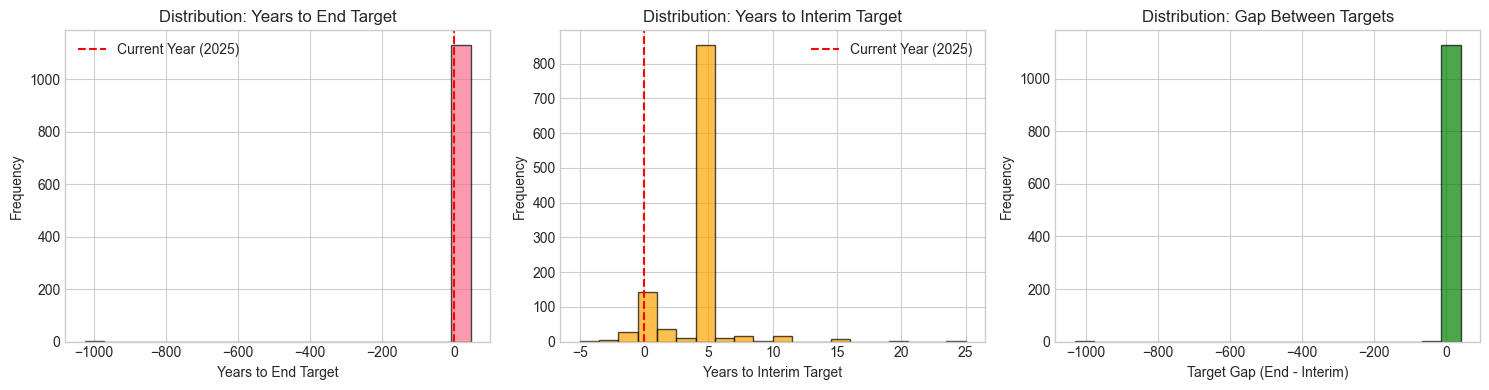

In [5]:
# Visualize distributions of numeric date-time features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Feature 1: Years to End Target
axes[0].hist(train_fe['years_to_end_target'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', label='Current Year (2025)')
axes[0].set_xlabel('Years to End Target')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution: Years to End Target')
axes[0].legend()

# Feature 2: Years to Interim Target
axes[1].hist(train_fe['years_to_interim_target'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(x=0, color='red', linestyle='--', label='Current Year (2025)')
axes[1].set_xlabel('Years to Interim Target')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution: Years to Interim Target')
axes[1].legend()

# Feature 3: Target Gap
axes[2].hist(train_fe['target_gap'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='green')
axes[2].set_xlabel('Target Gap (End - Interim)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution: Gap Between Targets')

plt.tight_layout()
plt.show()

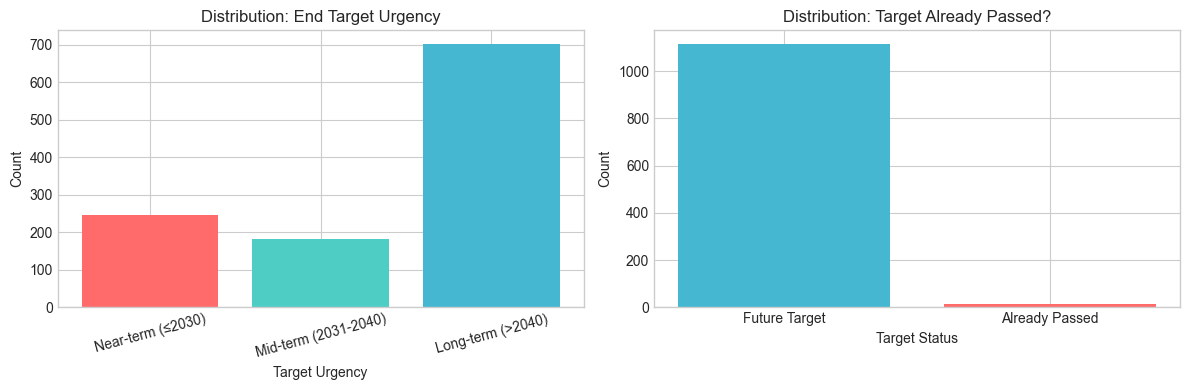

In [6]:
# Visualize categorical features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Feature 4: End Target Urgency
urgency_order = ['Near-term (≤2030)', 'Mid-term (2031-2040)', 'Long-term (>2040)', 'Unknown']
urgency_counts = train_fe['end_target_urgency'].value_counts().reindex(urgency_order).dropna()
axes[0].bar(urgency_counts.index, urgency_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0].set_xlabel('Target Urgency')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution: End Target Urgency')
axes[0].tick_params(axis='x', rotation=15)

# Feature 5: Target Already Passed
passed_counts = train_fe['target_already_passed'].value_counts()
labels = ['Future Target', 'Already Passed']
axes[1].bar(labels, [passed_counts.get(0, 0), passed_counts.get(1, 0)], color=['#45B7D1', '#FF6B6B'])
axes[1].set_xlabel('Target Status')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution: Target Already Passed?')

plt.tight_layout()
plt.show()

## 3. Explore Relationship with Target Variable

In [7]:
TARGET = 'Scope_3_coverage'

# Mean years_to_end_target by target class
print("Mean 'Years to End Target' by Scope_3_coverage class:")
grouped_mean = train_fe.groupby(TARGET)['years_to_end_target'].mean().sort_values()
print(grouped_mean)
print()

Mean 'Years to End Target' by Scope_3_coverage class:
Scope_3_coverage
Partial          12.218182
No               15.019231
Yes              19.500000
Not Specified    21.603239
Name: years_to_end_target, dtype: float64



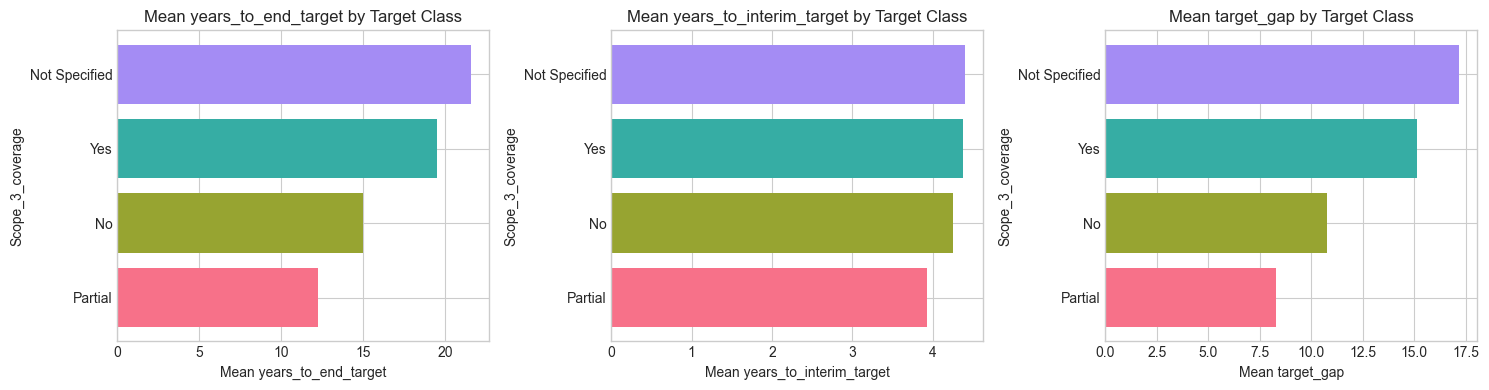

In [8]:
# Visualize: Grouped means for all numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, numeric_features):
    means = train_fe.groupby(TARGET)[feature].mean().sort_values()
    colors = sns.color_palette('husl', n_colors=len(means))
    ax.barh(means.index, means.values, color=colors)
    ax.set_xlabel(f'Mean {feature}')
    ax.set_ylabel('Scope_3_coverage')
    ax.set_title(f'Mean {feature} by Target Class')

plt.tight_layout()
plt.show()

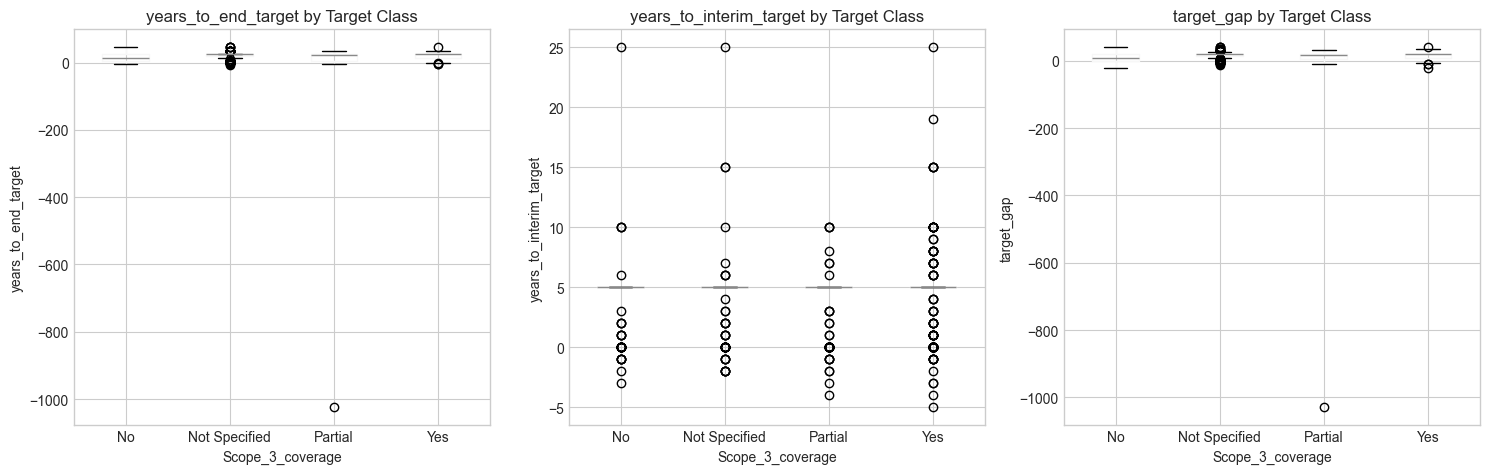

In [9]:
# Box plots: Distribution of date-time features by target class
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axes, numeric_features):
    train_fe.boxplot(column=feature, by=TARGET, ax=ax)
    ax.set_xlabel('Scope_3_coverage')
    ax.set_ylabel(feature)
    ax.set_title(f'{feature} by Target Class')

plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

In [10]:
# Class distribution by End Target Urgency
print("Class Distribution by End Target Urgency:")
urgency_target = pd.crosstab(train_fe['end_target_urgency'], train_fe[TARGET], normalize='index') * 100
print(urgency_target.round(1))

Class Distribution by End Target Urgency:
Scope_3_coverage        No  Not Specified  Partial   Yes
end_target_urgency                                      
Long-term (>2040)     13.7           27.5     16.5  42.4
Mid-term (2031-2040)  18.6            8.2     22.4  50.8
Near-term (≤2030)     31.8           15.9     25.7  26.5


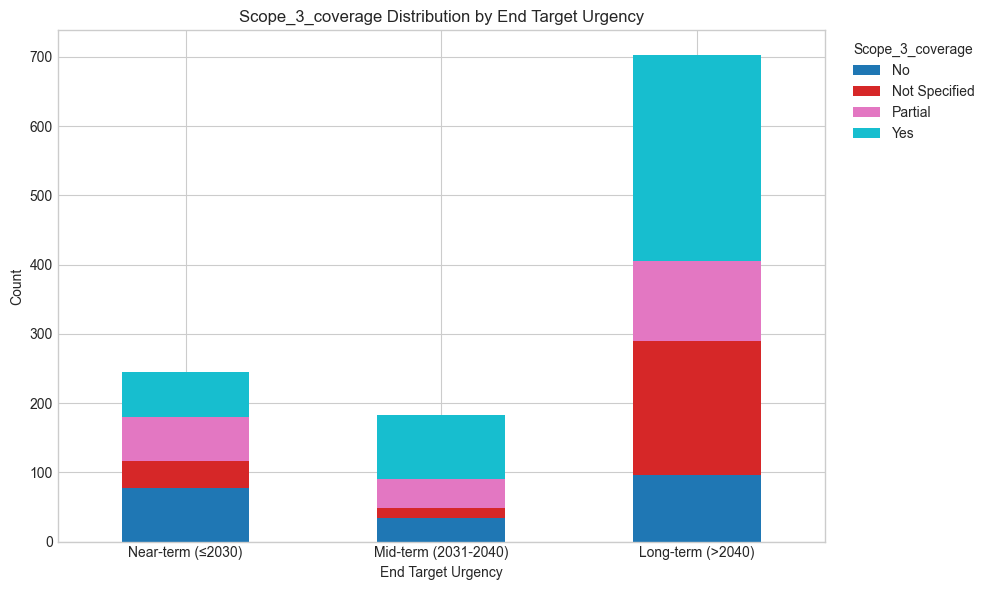

In [12]:
# Visualize: Stacked bar chart - Class imbalance by urgency
fig, ax = plt.subplots(figsize=(10, 6))

urgency_target_counts = pd.crosstab(train_fe['end_target_urgency'], train_fe[TARGET])
urgency_order = ['Near-term (≤2030)', 'Mid-term (2031-2040)', 'Long-term (>2040)']
urgency_target_counts = urgency_target_counts.reindex(urgency_order).dropna()

urgency_target_counts.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_xlabel('End Target Urgency')
ax.set_ylabel('Count')
ax.set_title('Scope_3_coverage Distribution by End Target Urgency')
ax.legend(title='Scope_3_coverage', bbox_to_anchor=(1.02, 1))
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

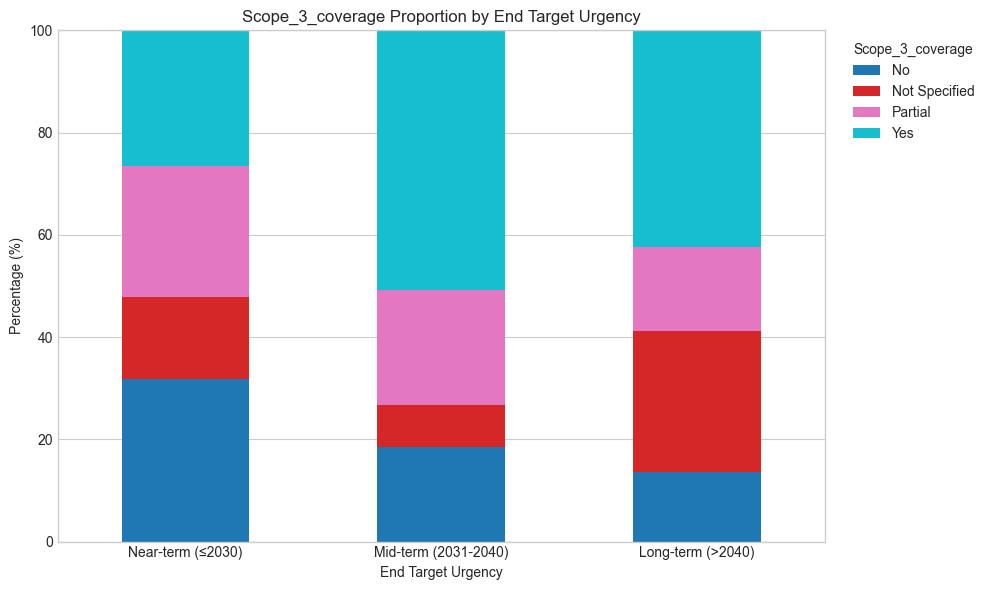

In [13]:
# Visualize: 100% stacked bar to see proportions
fig, ax = plt.subplots(figsize=(10, 6))

urgency_target_pct = pd.crosstab(train_fe['end_target_urgency'], train_fe[TARGET], normalize='index') * 100
urgency_target_pct = urgency_target_pct.reindex(urgency_order).dropna()

urgency_target_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_xlabel('End Target Urgency')
ax.set_ylabel('Percentage (%)')
ax.set_title('Scope_3_coverage Proportion by End Target Urgency')
ax.legend(title='Scope_3_coverage', bbox_to_anchor=(1.02, 1))
ax.tick_params(axis='x', rotation=0)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

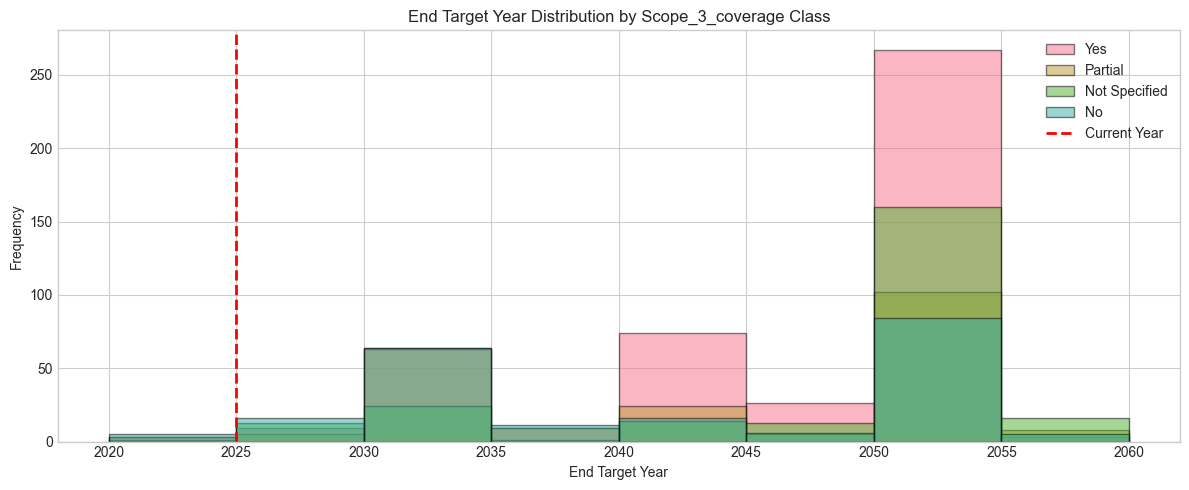

In [14]:
# Time series view: End target year distribution by Scope_3_coverage
fig, ax = plt.subplots(figsize=(12, 5))

for scope_class in train_fe[TARGET].unique():
    subset = train_fe[train_fe[TARGET] == scope_class]['End_target_year'].dropna()
    ax.hist(subset, bins=range(2020, 2065, 5), alpha=0.5, label=scope_class, edgecolor='black')

ax.axvline(x=CURRENT_YEAR, color='red', linestyle='--', linewidth=2, label='Current Year')
ax.set_xlabel('End Target Year')
ax.set_ylabel('Frequency')
ax.set_title('End Target Year Distribution by Scope_3_coverage Class')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Summary of Findings

In [16]:
print("="*70)
print("DATE-TIME FEATURE ENGINEERING SUMMARY")
print("="*70)

print("\n📊 FEATURES ENGINEERED:")
print("  1. years_to_end_target: Years until end target (negative = passed)")
print("  2. years_to_interim_target: Years until interim target")
print("  3. target_gap: Years between interim and end targets")
print("  4. end_target_urgency: Categorical (Near/Mid/Long-term)")
print("  5. target_already_passed: Binary (0/1)")

print("\n📈 KEY FINDINGS:")

# Finding 1: Mean years to end target by class
means = train_fe.groupby(TARGET)['years_to_end_target'].mean()
print(f"\n  1. Companies with 'Yes' Scope_3 have avg {means['Yes']:.1f} years to end target")
print(f"     Companies with 'No' Scope_3 have avg {means['No']:.1f} years to end target")

# Finding 2: Urgency breakdown
print(f"\n  2. Target Urgency Breakdown:")
urgency_pct = train_fe['end_target_urgency'].value_counts(normalize=True) * 100
for urg in urgency_order:
    if urg in urgency_pct.index:
        print(f"     - {urg}: {urgency_pct[urg]:.1f}%")

# Finding 3: Scope_3 coverage rate by urgency
print(f"\n  3. 'Yes' Scope_3 Rate by Urgency:")
for urg in urgency_order:
    if urg in urgency_target_pct.index:
        yes_pct = urgency_target_pct.loc[urg, 'Yes'] if 'Yes' in urgency_target_pct.columns else 0
        print(f"     - {urg}: {yes_pct:.1f}%")

print("\n" + "="*70)

DATE-TIME FEATURE ENGINEERING SUMMARY

📊 FEATURES ENGINEERED:
  1. years_to_end_target: Years until end target (negative = passed)
  2. years_to_interim_target: Years until interim target
  3. target_gap: Years between interim and end targets
  4. end_target_urgency: Categorical (Near/Mid/Long-term)
  5. target_already_passed: Binary (0/1)

📈 KEY FINDINGS:

  1. Companies with 'Yes' Scope_3 have avg 19.5 years to end target
     Companies with 'No' Scope_3 have avg 15.0 years to end target

  2. Target Urgency Breakdown:
     - Near-term (≤2030): 21.7%
     - Mid-term (2031-2040): 16.2%
     - Long-term (>2040): 62.2%

  3. 'Yes' Scope_3 Rate by Urgency:
     - Near-term (≤2030): 26.5%
     - Mid-term (2031-2040): 50.8%
     - Long-term (>2040): 42.4%



💡 Insight:Companies with mid-term targets (2031-2040) have the highest Scope_3 coverage rate (50.8%), while near-term targets have the lowest (26.5%). This suggests companies with more aggressive timelines may not yet have comprehensive Scope 3 reporting.